# Geração de Sinal Sintético Multivariado **Heterogêneo** (5 canais → 1 alvo)

Este notebook gera um dataset sintético **multivariado com natureza espectral distinta em cada canal**, projetado para que filtros wavelet **diferentes por canal** (per-channel DWT) sejam de fato justificados.

## Canais (cada um produzido por uma instância de `SyntheticSignalGenerator` com perfil próprio)
| Canal | Natureza | Banda dominante | Wavelet ideal |
|---|---|---|---|
| 0 | Baixa frequência (trend polinomial + 2 harmônicos lentos) | A_L (passa-baixa) | filtro largo, suporte grande |
| 1 | Média frequência (8 harmônicos médios) | D2/D3 | passa-banda intermediário |
| 2 | Alta frequência (osc. rápida + muito ruído) | D1 (passa-alta) | filtro agudo |
| 3 | Transientes esparsos + spikes | D1 localizado | suporte compacto (Haar/db2) |
| 4 | Chirp + muitas mudanças de regime (não-estacionário) | varia no tempo | wavelet adaptativa |

## Target **não-linear** univariado
$$y_i = w \cdot \text{clean}_{\text{last}} + \alpha\,(c_1\,c_3) + \beta\,(c_2^2 - c_4^2)$$
com $\alpha = 0.3$, $\beta = 0.2$, pesos lineares balanceados $[0.20, 0.20, 0.25, 0.15, 0.20]$.

Saídas em `data/`: `X_train/val/test.npy` no formato `(N, 256, 5)` + `y_*.npy` + `metadata.json` + `spectra.png` (validação espectral por canal).


In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('.')
from src.data_generator import MultivariateSyntheticGenerator
from config.experiment_config import (
    SYNTHETIC_SIGNAL_CONFIG, MULTIVARIATE_CONFIG,
    DATA_DIR, SEED,
)

np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print('SYNTHETIC_SIGNAL_CONFIG:'); [print(f'  {k}: {v}') for k,v in SYNTHETIC_SIGNAL_CONFIG.items()];
print('MULTIVARIATE_CONFIG:');     [print(f'  {k}: {v}') for k,v in MULTIVARIATE_CONFIG.items()];

SYNTHETIC_SIGNAL_CONFIG:
  n_samples: 5000
  sequence_length: 256
MULTIVARIATE_CONFIG:
  n_channels: 5
  channel_seeds: [42, 43, 44, 45, 46]
  channel_profiles: [{'trend_degree': 3, 'n_harmonics': 2, 'base_frequency': 0.002, 'regime_changes': 1, 'noise_level': 0.15, 'spike_probability': 0.0, 'spike_magnitude': 0.0}, {'trend_degree': 1, 'n_harmonics': 8, 'base_frequency': 0.01, 'regime_changes': 0, 'noise_level': 0.25, 'spike_probability': 0.0, 'spike_magnitude': 0.0}, {'trend_degree': 0, 'n_harmonics': 3, 'base_frequency': 0.08, 'regime_changes': 0, 'noise_level': 0.4, 'spike_probability': 0.0, 'spike_magnitude': 0.0}, {'trend_degree': 0, 'n_harmonics': 1, 'base_frequency': 0.005, 'regime_changes': 0, 'noise_level': 0.1, 'spike_probability': 0.05, 'spike_magnitude': 4.0}, {'trend_degree': 1, 'n_harmonics': 3, 'base_frequency': 0.02, 'regime_changes': 6, 'noise_level': 0.3, 'spike_probability': 0.0, 'spike_magnitude': 0.0}]
  target_linear_weights: [0.2, 0.2, 0.25, 0.15, 0.2]
  target_a

## 1. Gerar sinal multivariado

In [2]:
generator = MultivariateSyntheticGenerator(
    n_samples=SYNTHETIC_SIGNAL_CONFIG['n_samples'],
    n_channels=MULTIVARIATE_CONFIG['n_channels'],
    channel_seeds=MULTIVARIATE_CONFIG['channel_seeds'],
    channel_profiles=MULTIVARIATE_CONFIG['channel_profiles'],
    target_linear_weights=MULTIVARIATE_CONFIG['target_linear_weights'],
    target_alpha=MULTIVARIATE_CONFIG['target_alpha'],
    target_beta=MULTIVARIATE_CONFIG['target_beta'],
)

noisy, clean = generator.generate()
print('noisy:', noisy.shape, 'clean:', clean.shape)
for meta in generator.metadata['per_channel']:
    prof = meta['profile']
    print(
        f"  canal {meta['channel']} (seed={meta['seed']}, base_freq={prof['base_frequency']:.4f}, "
        f"n_harm={prof['n_harmonics']}, regimes={prof['regime_changes']}, "
        f"noise={prof['noise_level']:.2f}, spikes_p={prof['spike_probability']:.3f}): "
        f"SNR={meta['snr_db']:.2f} dB, spikes={meta['n_spikes']}"
    )


noisy: (5000, 5) clean: (5000, 5)
  canal 0 (seed=42, base_freq=0.0020, n_harm=2, regimes=1, noise=0.15, spikes_p=0.000): SNR=16.48 dB, spikes=0
  canal 1 (seed=43, base_freq=0.0100, n_harm=8, regimes=0, noise=0.25, spikes_p=0.000): SNR=12.10 dB, spikes=0
  canal 2 (seed=44, base_freq=0.0800, n_harm=3, regimes=0, noise=0.40, spikes_p=0.000): SNR=7.90 dB, spikes=0
  canal 3 (seed=45, base_freq=0.0050, n_harm=1, regimes=0, noise=0.10, spikes_p=0.050): SNR=19.91 dB, spikes=251
  canal 4 (seed=46, base_freq=0.0200, n_harm=3, regimes=6, noise=0.30, spikes_p=0.000): SNR=10.54 dB, spikes=0


## 2. Visualizar canais (clean vs noisy)

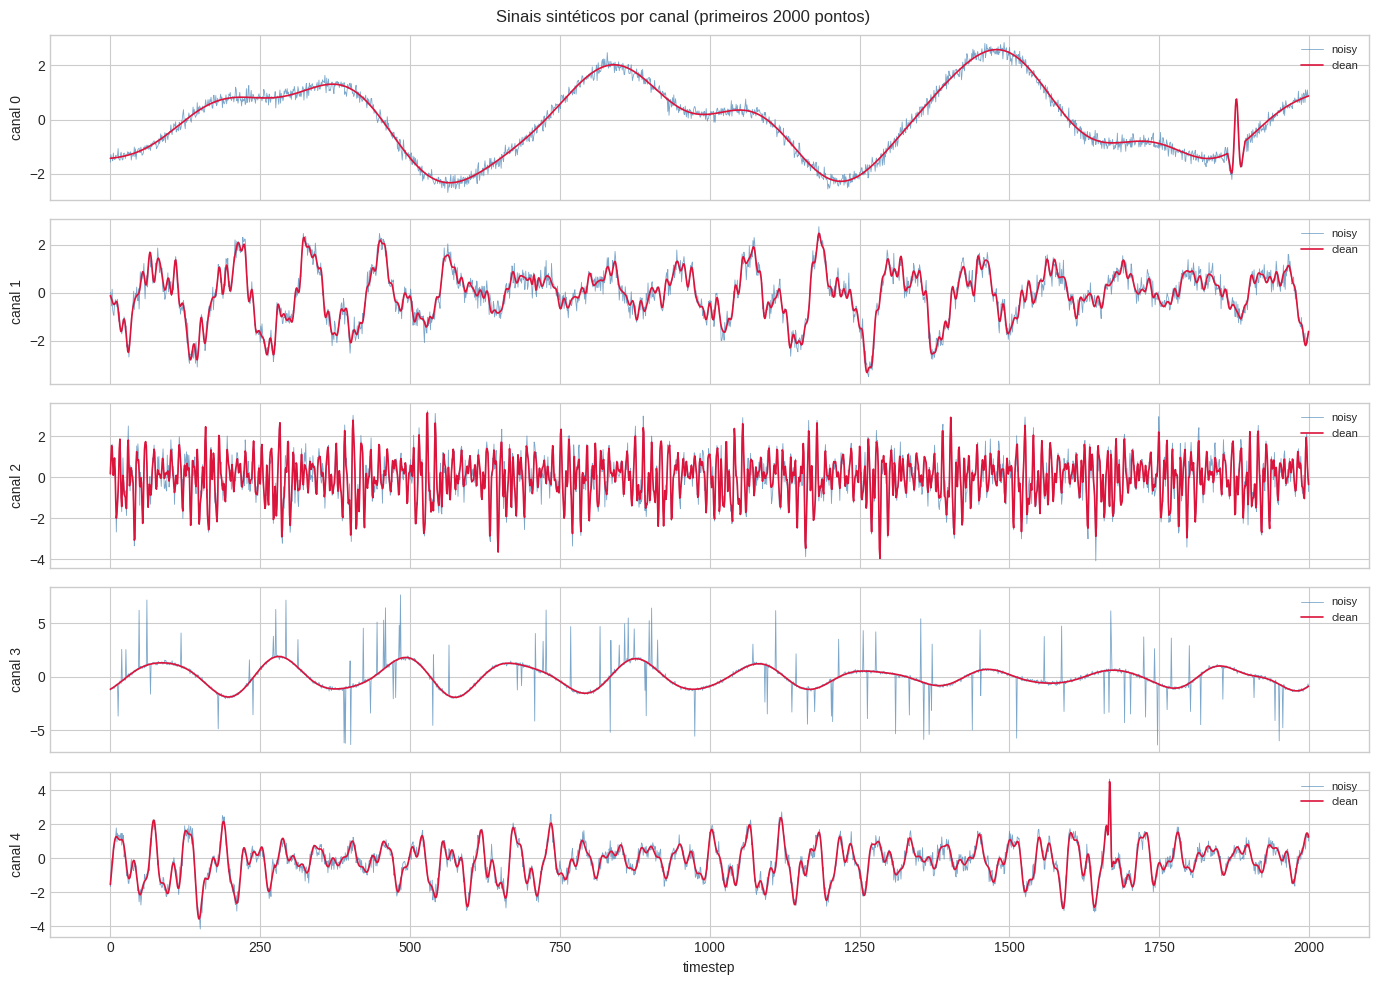

In [3]:
T = noisy.shape[0]
C = noisy.shape[1]
win_lo, win_hi = 0, min(2000, T)

fig, axes = plt.subplots(C, 1, figsize=(14, 2.0 * C), sharex=True)
for c in range(C):
    axes[c].plot(noisy[win_lo:win_hi, c], color='steelblue', lw=0.6, alpha=0.7, label='noisy')
    axes[c].plot(clean[win_lo:win_hi, c], color='crimson',   lw=1.2,             label='clean')
    axes[c].set_ylabel(f'canal {c}')
    axes[c].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('timestep')
plt.suptitle(f'Sinais sintéticos por canal (primeiros {win_hi-win_lo} pontos)', fontsize=12)
plt.tight_layout(); plt.show()

## 3. Correlação entre canais (clean)

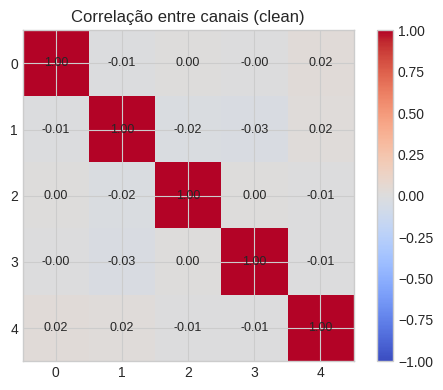

In [4]:
corr = np.corrcoef(clean.T)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
for i in range(C):
    for j in range(C):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_xticks(range(C)); ax.set_yticks(range(C))
ax.set_title('Correlação entre canais (clean)')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 3.1 Espectro Welch por canal (valida heterogeneidade espectral)

Cada canal deve apresentar pico em uma banda diferente. Se os picos coincidirem, os perfis precisam ser revisados.


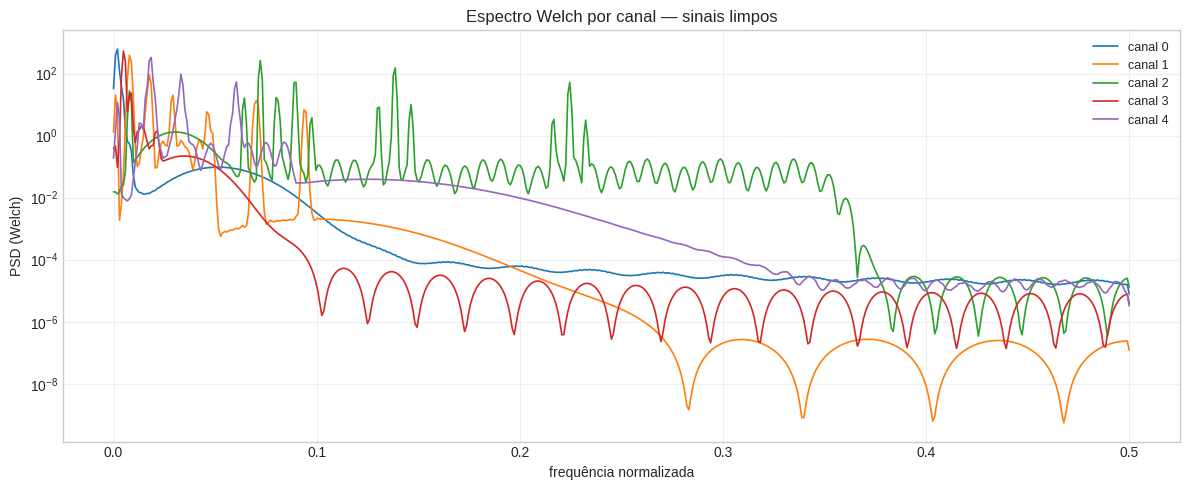

Picos espectrais por canal:
  canal 0: f_peak ≈ 0.0020
  canal 1: f_peak ≈ 0.0078
  canal 2: f_peak ≈ 0.0723
  canal 3: f_peak ≈ 0.0049
  canal 4: f_peak ≈ 0.0186


In [5]:
from scipy import signal as sp_signal

fig, ax = plt.subplots(figsize=(12, 5))
peak_freqs = []
for c in range(C):
    f, Pxx = sp_signal.welch(clean[:, c], fs=1.0, nperseg=min(1024, len(clean) // 4))
    ax.semilogy(f, Pxx, lw=1.2, label=f'canal {c}')
    # ignora o bin DC para achar o pico real
    idx = int(np.argmax(Pxx[1:])) + 1
    peak_freqs.append(f[idx])

ax.set_xlabel('frequência normalizada')
ax.set_ylabel('PSD (Welch)')
ax.set_title('Espectro Welch por canal — sinais limpos')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / 'spectra.png', dpi=120, bbox_inches='tight')
plt.show()

print('Picos espectrais por canal:')
for c, fp in enumerate(peak_freqs):
    print(f'  canal {c}: f_peak ≈ {fp:.4f}')


## 4. Janelamento e target ponderado

In [6]:
X, y = generator.create_regression_dataset(
    sequence_length=SYNTHETIC_SIGNAL_CONFIG['sequence_length'],
    horizon=MULTIVARIATE_CONFIG['horizon'],
    stride=MULTIVARIATE_CONFIG['stride'],
)
print('X:', X.shape, X.dtype, '   y:', y.shape, y.dtype)
print('target linear weights:', generator.target_linear_weights.tolist())
print(f'target alpha={generator.target_alpha}, beta={generator.target_beta}')
print(f'y stats: mean={y.mean():.4f}, std={y.std():.4f}, min={y.min():.4f}, max={y.max():.4f}')


X: (4744, 256, 5) float32    y: (4744,) float32
target linear weights: [0.1999999999998, 0.1999999999998, 0.24999999999974998, 0.14999999999984998, 0.1999999999998]
target alpha=0.3, beta=0.2
y stats: mean=0.0096, std=0.6962, min=-3.0737, max=5.8154


### 4.1 Distribuição do target

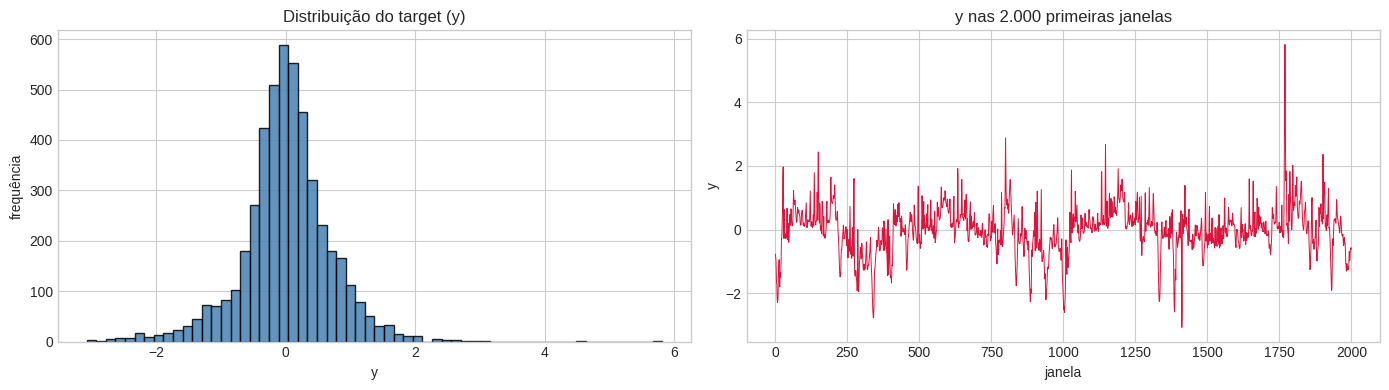

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y, bins=60, color='steelblue', edgecolor='k', alpha=0.85)
axes[0].set_title('Distribuição do target (y)')
axes[0].set_xlabel('y'); axes[0].set_ylabel('frequência')
axes[1].plot(y[:2000], color='crimson', lw=0.7)
axes[1].set_title('y nas 2.000 primeiras janelas')
axes[1].set_xlabel('janela'); axes[1].set_ylabel('y')
plt.tight_layout(); plt.show()

## 5. Split treino/val/teste (cronológico 70/15/15)

In [8]:
n = len(X)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X[:train_end],          y[:train_end]
X_val,   y_val   = X[train_end:val_end],   y[train_end:val_end]
X_test,  y_test  = X[val_end:],            y[val_end:]

print('Train:', X_train.shape, y_train.shape)
print('Val:  ', X_val.shape,   y_val.shape)
print('Test: ', X_test.shape,  y_test.shape)
print(f'Total: {n} janelas ({len(X_train)/n:.1%} / {len(X_val)/n:.1%} / {len(X_test)/n:.1%})')

Train: (3320, 256, 5) (3320,)
Val:   (712, 256, 5) (712,)
Test:  (712, 256, 5) (712,)
Total: 4744 janelas (70.0% / 15.0% / 15.0%)


## 6. Salvar em `data/`

In [9]:
np.save(DATA_DIR / 'X_train.npy', X_train)
np.save(DATA_DIR / 'y_train.npy', y_train)
np.save(DATA_DIR / 'X_val.npy',   X_val)
np.save(DATA_DIR / 'y_val.npy',   y_val)
np.save(DATA_DIR / 'X_test.npy',  X_test)
np.save(DATA_DIR / 'y_test.npy',  y_test)

metadata = {**generator.metadata,
            'split': {'train': len(X_train), 'val': len(X_val), 'test': len(X_test)}}
with open(DATA_DIR / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

for p in sorted(DATA_DIR.glob('*')):
    sz = p.stat().st_size / (1024 * 1024)
    print(f'  {p.name:20s}  {sz:7.2f} MB')

  X_test.npy               3.48 MB
  X_train.npy             16.21 MB
  X_val.npy                3.48 MB
  metadata.json            0.00 MB
  spectra.png              0.16 MB
  y_test.npy               0.00 MB
  y_train.npy              0.01 MB
  y_val.npy                0.00 MB
